In [ ]:
# Instalamos la librería para descargar datasets desde UCI
!pip install ucimlrepo

In [ ]:
# Librerías principales para análisis de datos
import pandas as pd
import numpy as np

# Librerías para gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Librería para cargar datasets desde UCI
from ucimlrepo import fetch_ucirepo

In [ ]:
# Cargamos el dataset desde UCI
online_shoppers = fetch_ucirepo(id=468)

# Separamos las variables predictoras, X, y la variable objetivo, y
X = online_shoppers.data.features
y = online_shoppers.data.targets

# Unimos X e y en un solo DataFrame para analizarlo más cómodamente
df = pd.concat([X, y], axis=1)

# Mostramos las primeras filas
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [ ]:
df.shape

(12330, 18)

In [ ]:
df.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [ ]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [ ]:
df.isnull().sum()

,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


In [ ]:
df['Revenue'].value_counts()

,count
Revenue,
False,10422
True,1908


In [ ]:
df['Revenue'].value_counts(normalize=True) * 100

,proportion
Revenue,
False,84.525547
True,15.474453


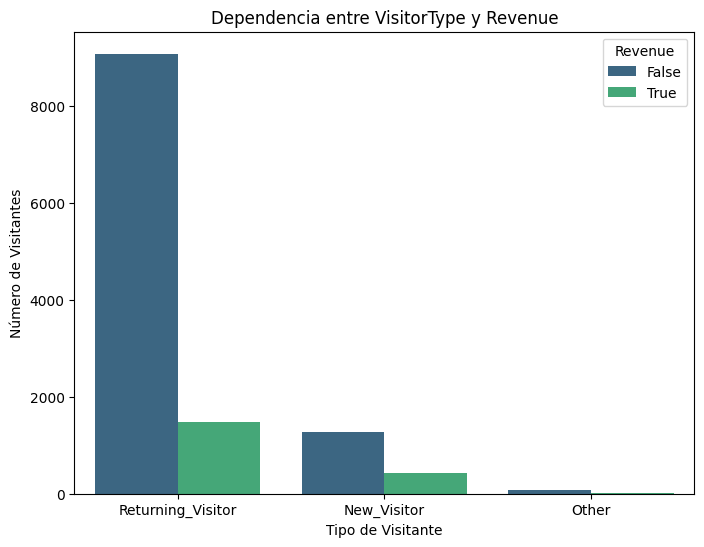

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='VisitorType', hue='Revenue', data=df, palette='viridis')
plt.title('Dependencia entre VisitorType y Revenue')
plt.xlabel('Tipo de Visitante')
plt.ylabel('Número de Visitantes')
plt.show()

/tmp/ipykernel_498/2322555956.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Month', data=df[df['Revenue'] == True], palette='viridis', order=df['Month'].value_counts().index)


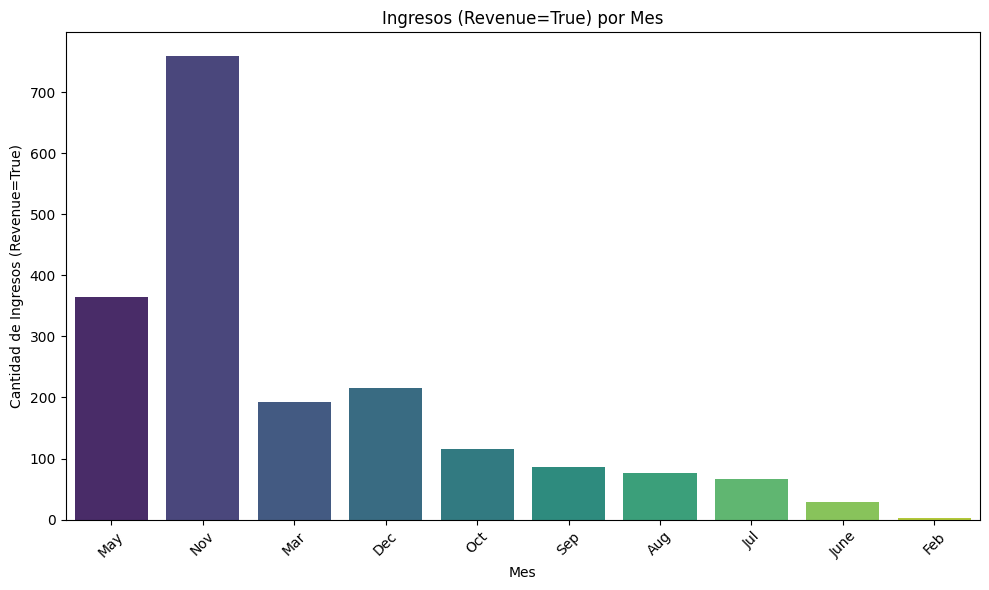

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Month', data=df[df['Revenue'] == True], palette='viridis', order=df['Month'].value_counts().index)
plt.title('Ingresos (Revenue=True) por Mes')
plt.xlabel('Mes')
plt.ylabel('Cantidad de Ingresos (Revenue=True)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_498/3221906519.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_counts = df_revenue_true.groupby(bins)['Revenue'].count().reset_index()
/tmp/ipykernel_498/3221906519.py:17: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x='Midpoint', y='Revenue_Count', data=revenue_counts, marker='o', palette='viridis')


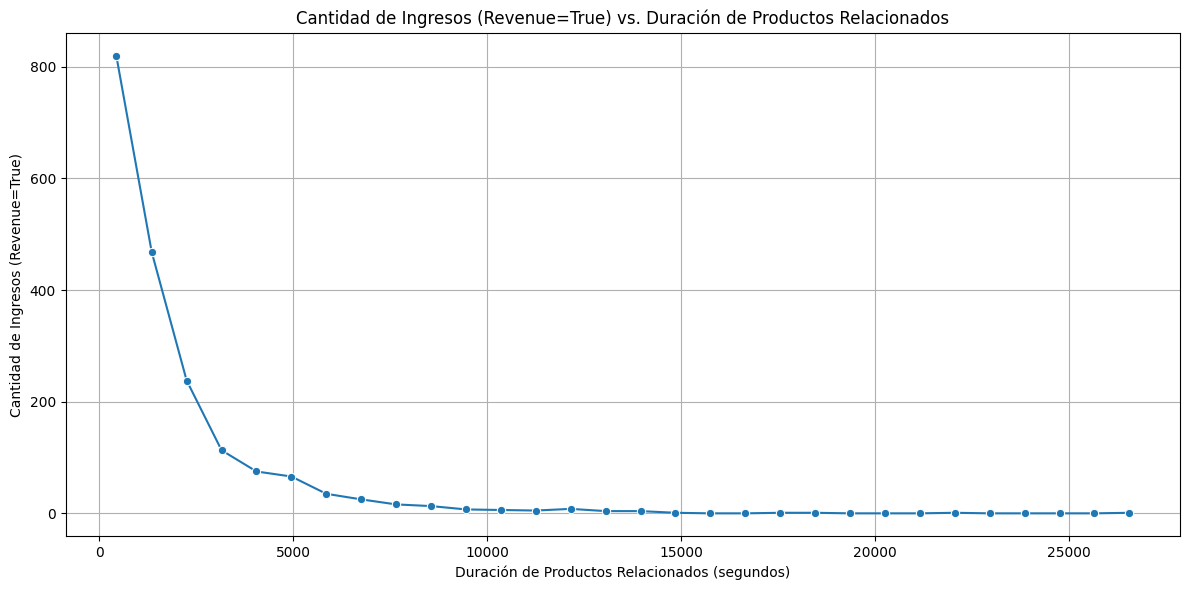

In [ ]:
# Filtramos el DataFrame para obtener solo las filas donde Revenue es True
df_revenue_true = df[df['Revenue'] == True]

# Creamos bins para ProductRelated_Duration
# Usamos 30 bins para tener una buena granularidad
bins = pd.cut(df_revenue_true['ProductRelated_Duration'], bins=30)

# Contamos la cantidad de Revenue=True en cada bin
revenue_counts = df_revenue_true.groupby(bins)['Revenue'].count().reset_index()
revenue_counts.columns = ['ProductRelated_Duration_Bin', 'Revenue_Count']

# Extraemos el punto medio de cada bin para usarlo en el eje X del gráfico
revenue_counts['Midpoint'] = revenue_counts['ProductRelated_Duration_Bin'].apply(lambda x: x.mid)

# Creamos el gráfico de línea
plt.figure(figsize=(12, 6))
sns.lineplot(x='Midpoint', y='Revenue_Count', data=revenue_counts, marker='o', palette='viridis')
plt.title('Cantidad de Ingresos (Revenue=True) vs. Duración de Productos Relacionados')
plt.xlabel('Duración de Productos Relacionados (segundos)')
plt.ylabel('Cantidad de Ingresos (Revenue=True)')
plt.grid(True)
plt.tight_layout()
plt.show()

### Gráfico de Ingresos vs. Duración de Productos Relacionados (en Minutos)

/tmp/ipykernel_498/407482449.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_counts_min = df_revenue_true_min.groupby(bins_minutes)['Revenue'].count().reset_index()
/tmp/ipykernel_498/407482449.py:20: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x='Midpoint', y='Revenue_Count', data=revenue_counts_min, marker='o', palette='viridis')


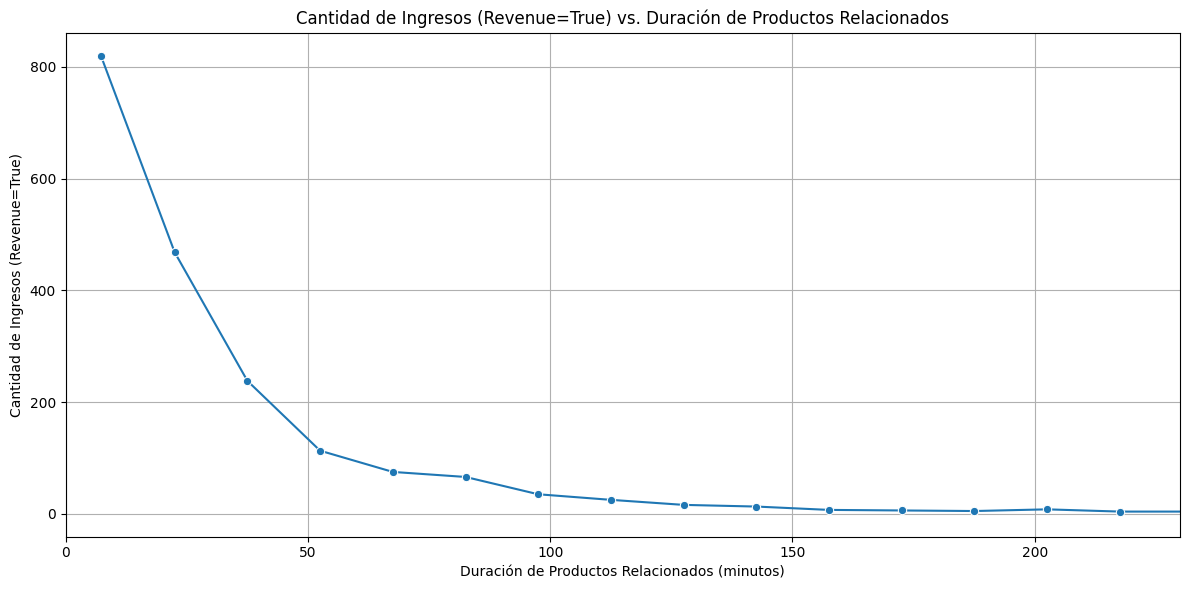

In [ ]:
# Filtramos el DataFrame para obtener solo las filas donde Revenue es True
df_revenue_true_min = df[df['Revenue'] == True].copy()

# Convertimos ProductRelated_Duration a minutos
df_revenue_true_min['ProductRelated_Duration_Minutes'] = df_revenue_true_min['ProductRelated_Duration'] / 60

# Creamos bins para ProductRelated_Duration_Minutes
# Usamos 30 bins para tener una buena granularidad
bins_minutes = pd.cut(df_revenue_true_min['ProductRelated_Duration_Minutes'], bins=30)

# Contamos la cantidad de Revenue=True en cada bin
revenue_counts_min = df_revenue_true_min.groupby(bins_minutes)['Revenue'].count().reset_index()
revenue_counts_min.columns = ['ProductRelated_Duration_Bin_Minutes', 'Revenue_Count']

# Extraemos el punto medio de cada bin para usarlo en el eje X del gráfico
revenue_counts_min['Midpoint'] = revenue_counts_min['ProductRelated_Duration_Bin_Minutes'].apply(lambda x: x.mid)

# Creamos el gráfico de línea
plt.figure(figsize=(12, 6))
sns.lineplot(x='Midpoint', y='Revenue_Count', data=revenue_counts_min, marker='o', palette='viridis')
plt.title('Cantidad de Ingresos (Revenue=True) vs. Duración de Productos Relacionados')
plt.xlabel('Duración de Productos Relacionados (minutos)')
plt.ylabel('Cantidad de Ingresos (Revenue=True)')
plt.grid(True)
plt.xlim(0, 230) # Ajustar el límite del eje x a 230 minutos
plt.tight_layout()
plt.show()

### Preparación de Datos para Machine Learning

In [ ]:
# Aseguramos que la librería esté instalada para que la celda funcione independientemente
!pip install ucimlrepo

# Añadimos las importaciones necesarias y la definición de 'df'
import pandas as pd
from ucimlrepo import fetch_ucirepo

# Cargamos el dataset desde UCI (copia de la definición de df desde una celda anterior)
online_shoppers = fetch_ucirepo(id=468)
X_features = online_shoppers.data.features
y_target = online_shoppers.data.targets
df = pd.concat([X_features, y_target], axis=1)

# Copiamos el DataFrame original para no modificarlo directamente
df_ml = df.copy()

# Convertir variables categóricas a numéricas usando One-Hot Encoding
df_ml = pd.get_dummies(df_ml, columns=['Month', 'VisitorType'], drop_first=True)

# Convertir variables booleanas a enteros (0 y 1)
df_ml['Weekend'] = df_ml['Weekend'].astype(int)
df_ml['Revenue'] = df_ml['Revenue'].astype(int)

df_ml.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True


In [ ]:
import pandas as pd

# Código opcional para cargar desde el archivo local CSV si lo prefieres
# df_desde_csv = pd.read_csv('/content/online_shoppers_intention.csv')
# display(df_desde_csv.head())

print("El archivo CSV está disponible, pero el modelo actual usa los datos descargados vía API de UCI.")

El archivo CSV está disponible, pero el modelo actual usa los datos descargados vía API de UCI.


### División de Datos en Conjuntos de Entrenamiento y Prueba

In [ ]:
from sklearn.model_selection import train_test_split

# Separar características (X) y la variable objetivo (y)
X = df_ml.drop('Revenue', axis=1)
y = df_ml['Revenue']

# Dividir los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} muestras")

Tamaño del conjunto de entrenamiento: 9864 muestras
Tamaño del conjunto de prueba: 2466 muestras


### Entrenamiento del Modelo de Clasificación (Random Forest)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Inicializar y entrenar el modelo de Random Forest
# Usamos un random_state para reproducibilidad
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

print("Modelo de Random Forest entrenado exitosamente!")

Modelo de Random Forest entrenado exitosamente!


### Evaluación del Modelo

Accuracy: 0.8954
Precision: 0.7403
Recall: 0.5000
F1-Score: 0.5969
AUC-ROC: 0.9162


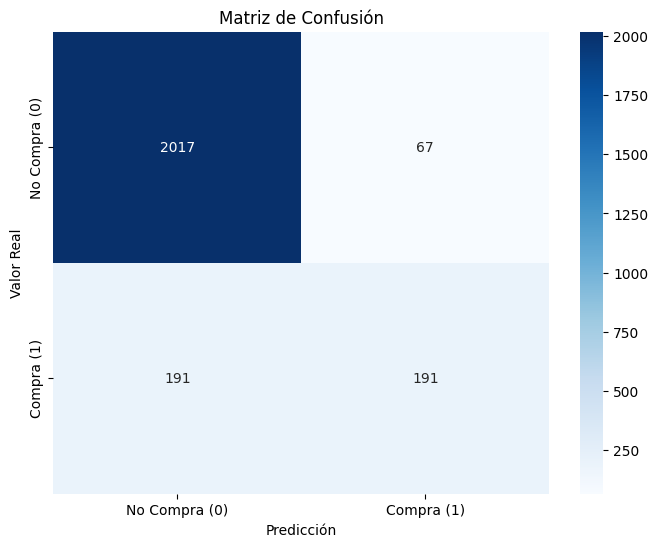


Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      2084
           1       0.74      0.50      0.60       382

    accuracy                           0.90      2466
   macro avg       0.83      0.73      0.77      2466
weighted avg       0.89      0.90      0.89      2466



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Realizar predicciones en el conjunto de prueba
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1] # Probabilidades de la clase positiva (Revenue=True)

# Evaluar el rendimiento del modelo
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC-ROC: {roc_auc:.4f}")

# Mostrar matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Compra (0)', 'Compra (1)'],
            yticklabels=['No Compra (0)', 'Compra (1)'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()

# Mostrar reporte de clasificación
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

Recomendaciones de chat

In [ ]:
import pandas as pd
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# --- Re-execute necessary steps to define X and model for standalone execution ---

# 1. Cargamos el dataset desde UCI (similar a celda xpseyGhB7haf)
online_shoppers = fetch_ucirepo(id=468)
X_features = online_shoppers.data.features
y_target = online_shoppers.data.targets
df = pd.concat([X_features, y_target], axis=1)

# 2. Preparamos los datos para Machine Learning (similar a celda aac2ae13)
df_ml = df.copy()
df_ml = pd.get_dummies(df_ml, columns=['Month', 'VisitorType'], drop_first=True)
df_ml['Weekend'] = df_ml['Weekend'].astype(int)
df_ml['Revenue'] = df_ml['Revenue'].astype(int)

# 3. Separamos características (X) y la variable objetivo (y) (similar a celda 32b6288b)
X = df_ml.drop('Revenue', axis=1)
y = df_ml['Revenue']

# Dividimos los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Entrenamos el modelo de Random Forest (similar a celda 0df2373b)
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# --- Original code for feature importance ---
# Importancia de variables del modelo
importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': model.feature_importances_
}).sort_values(by='Importancia', ascending=False)

print(importancias.head(15))

                   Variable  Importancia
8                PageValues     0.379043
7                 ExitRates     0.099249
5   ProductRelated_Duration     0.095082
4            ProductRelated     0.065778
6               BounceRates     0.056568
1   Administrative_Duration     0.051619
0            Administrative     0.037074
13              TrafficType     0.027437
21                Month_Nov     0.027081
12                   Region     0.025527
3    Informational_Duration     0.021634
11                  Browser     0.016371
10         OperatingSystems     0.015786
2             Informational     0.014231
20                Month_May     0.012080


In [ ]:
# Crear un DataFrame con resultados del test
resultados_prediccion = X_test.copy()
resultados_prediccion['Compra_real'] = y_test.values
resultados_prediccion['Probabilidad_compra'] = y_proba
resultados_prediccion['Prediccion_compra'] = y_pred

# Clasificar usuarios según probabilidad de compra
def clasificar_usuario(prob):
    if prob >= 0.70:
        return "Alta probabilidad de compra"
    elif prob >= 0.40:
        return "Probabilidad media de compra"
    else:
        return "Baja probabilidad de compra"

resultados_prediccion['Segmento'] = resultados_prediccion['Probabilidad_compra'].apply(clasificar_usuario)

resultados_prediccion[['Compra_real', 'Prediccion_compra', 'Probabilidad_compra', 'Segmento']].head(20)

,Compra_real,Prediccion_compra,Probabilidad_compra,Segmento
4722,0,0,0.01,Baja probabilidad de compra
6835,0,0,0.09,Baja probabilidad de compra
5524,1,1,0.77,Alta probabilidad de compra
663,0,0,0.00,Baja probabilidad de compra
136,0,0,0.02,Baja probabilidad de compra
1194,0,0,0.01,Baja probabilidad de compra
11507,1,0,0.08,Baja probabilidad de compra
11214,0,0,0.21,Baja probabilidad de compra
7656,0,0,0.11,Baja probabilidad de compra
7786,0,0,0.07,Baja probabilidad de compra


In [ ]:
def predecir_compra(nuevo_usuario):
    probabilidad = model.predict_proba(nuevo_usuario)[:, 1][0]
    prediccion = model.predict(nuevo_usuario)[0]

    if probabilidad >= 0.70:
        accion = "Alta probabilidad de compra: facilitar checkout y evitar descuentos innecesarios."
    elif probabilidad >= 0.40:
        accion = "Probabilidad media: ofrecer incentivo como descuento, envío gratis o recordatorio."
    else:
        accion = "Baja probabilidad: incluir en campañas de remarketing."

    return {
        "Predicción": "Compra" if prediccion == 1 else "No compra",
        "Probabilidad de compra": round(probabilidad, 2),
        "Acción recomendada": accion
    }

# Variables más importantes:

"PageValues" es, por lejos, la característica más importante para predecir si un visitante realizará una compra. Esto tiene mucho sentido en un contexto de e-commerce, ya que "PageValues" representa la importancia de una página web visitada por el usuario, lo que está directamente relacionado con la probabilidad de transacción. Un "PageValue" alto sugiere que el usuario está muy interesado en las páginas que finalmente conducen a una conversión.
"ProductRelated_Duration", "ExitRates", "ProductRelated", y "BounceRates" también son muy relevantes. La duración de las visitas a páginas de productos, las tasas de salida y rebote, y el número de páginas de productos visitadas, son indicadores clave del compromiso y la intención de compra del usuario.
Las variables relacionadas con el tiempo y la interacción ("Administrative_Duration", "Administrative") también son significativas, aunque en menor medida que las anteriores.
Características como el tipo de visitante ("VisitorType_Other", "VisitorType_Returning_Visitor"), la región, el tipo de tráfico, el mes y el navegador tienen una importancia menor en este modelo, pero aún contribuyen a la predicción.

# Para este problema yo priorizaría:

-Recall de compra, si la tienda quiere detectar la mayor cantidad posible de usuarios con intención de compra.
-Precision de compra, si la tienda no quiere gastar incentivos en usuarios que probablemente no compren.
-AUC-ROC, para evaluar qué tan bien separa el modelo entre compradores y no compradores.

In [ ]:
codigo_app = """
import streamlit as st
import pandas as pd
import numpy as np

st.set_page_config(
    page_title="PredictBuy Portal",
    page_icon="🛒",
    layout="wide"
)

st.title("🛒 PredictBuy Portal")
st.subheader("Predicción de finalización de compra para ecommerce")

st.write(
    "PredictBuy permite a las tiendas online cargar un dataset de ecommerce "
    "y obtener una predicción sobre qué usuarios tienen mayor probabilidad de finalizar una compra."
)

st.divider()

st.header("1. Cargar dataset")

archivo = st.file_uploader(
    "Subí un archivo CSV con datos de navegación o comportamiento de usuarios",
    type=["csv"]
)

if archivo is not None:
    df = pd.read_csv(archivo)

    st.success("Dataset cargado correctamente")

    col1, col2, col3 = st.columns(3)

    with col1:
        st.metric("Filas", df.shape[0])

    with col2:
        st.metric("Columnas", df.shape[1])

    with col3:
        st.metric("Valores nulos", int(df.isnull().sum().sum()))

    st.subheader("Vista previa del dataset")
    st.dataframe(df.head())

    st.divider()

    st.header("2. Análisis automático del dataset")

    columnas_numericas = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
    columnas_categoricas = df.select_dtypes(include=["object", "bool"]).columns.tolist()

    col1, col2 = st.columns(2)

    with col1:
        st.write("Variables numéricas detectadas:")
        st.write(columnas_numericas)

    with col2:
        st.write("Variables categóricas detectadas:")
        st.write(columnas_categoricas)

    st.divider()

    st.header("3. Predicción de finalización de compra")

    st.write(
        "En esta versión demo, el portal estima una probabilidad de compra para cada registro. "
        "En una implementación real, esta sección se conectaría con el modelo Random Forest entrenado en Colab."
    )

    np.random.seed(42)
    df_resultado = df.copy()

    df_resultado["probabilidad_compra"] = np.random.uniform(0.05, 0.95, size=len(df_resultado))

    def clasificar(prob):
        if prob >= 0.70:
            return "Alta probabilidad"
        elif prob >= 0.40:
            return "Probabilidad media"
        else:
            return "Baja probabilidad"

    def recomendar(prob):
        if prob >= 0.70:
            return "Facilitar checkout y evitar descuentos innecesarios"
        elif prob >= 0.40:
            return "Ofrecer incentivo: descuento, envío gratis o recordatorio"
        else:
            return "Incluir en campaña de remarketing"

    df_resultado["segmento"] = df_resultado["probabilidad_compra"].apply(clasificar)
    df_resultado["accion_recomendada"] = df_resultado["probabilidad_compra"].apply(recomendar)

    st.subheader("Resultados de predicción")
    st.dataframe(
        df_resultado[["probabilidad_compra", "segmento", "accion_recomendada"]].head(20)
    )

    st.divider()

    st.header("4. Segmentación de usuarios")

    col1, col2, col3 = st.columns(3)

    with col1:
        st.metric("Alta probabilidad", int((df_resultado["segmento"] == "Alta probabilidad").sum()))

    with col2:
        st.metric("Probabilidad media", int((df_resultado["segmento"] == "Probabilidad media").sum()))

    with col3:
        st.metric("Baja probabilidad", int((df_resultado["segmento"] == "Baja probabilidad").sum()))

    st.bar_chart(df_resultado["segmento"].value_counts())

    st.divider()

    st.header("5. Recomendaciones comerciales")

    st.markdown(
        '''
        - **Alta probabilidad de compra:** simplificar checkout y evitar descuentos innecesarios.
        - **Probabilidad media:** ofrecer incentivo, envío gratis o recordatorio.
        - **Baja probabilidad:** incluir al usuario en campañas de remarketing.
        '''
    )

    st.divider()

    st.header("6. Descargar resultados")

    csv = df_resultado.to_csv(index=False).encode("utf-8")

    st.download_button(
        label="Descargar predicciones en CSV",
        data=csv,
        file_name="predictbuy_resultados.csv",
        mime="text/csv"
    )

else:
    st.info("Subí un archivo CSV para comenzar.")
"""

with open("app.py", "w", encoding="utf-8") as f:
    f.write(codigo_app)

In [ ]:
from google.colab import files
files.download("app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
requirements = """
streamlit
pandas
numpy
"""

with open("requirements.txt", "w", encoding="utf-8") as f:
    f.write(requirements)

In [ ]:
from google.colab import files
files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Instalar librería para traer datasets desde UCI
!pip install ucimlrepo

# Importar librerías
import pandas as pd
from ucimlrepo import fetch_ucirepo
from google.colab import files

# ==========================================
# GUARDAR MODELO Y ARCHIVOS DE PRUEBA
# ==========================================

import joblib
from google.colab import files

# Guardar el modelo entrenado SOLO con X_train e y_train
joblib.dump(model, "modelo_random_forest.pkl")

# Guardar las columnas reales con las que fue entrenado el modelo
joblib.dump(X_train.columns.tolist(), "columnas_modelo.pkl")

# Crear un dataset de test en formato original para probar en la app
# Usamos los índices de X_test para recuperar las filas originales desde df
df_test_original = df.loc[X_test.index].copy()

# Guardar el dataset de prueba
df_test_original.to_csv("online_shoppers_test.csv", index=False)

# Opcional: crear una muestra chica del test para probar rápido la app
df_test_muestra_100 = df_test_original.sample(100, random_state=42)
df_test_muestra_100.to_csv("online_shoppers_test_muestra_100.csv", index=False)

# Descargar archivos
files.download("modelo_random_forest.pkl")
files.download("columnas_modelo.pkl")
files.download("online_shoppers_test.csv")
files.download("online_shoppers_test_muestra_100.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==========================================
# GENERAR DATASET COMPLETO DE TEST PARA LA APP
# ==========================================

from google.colab import files

# Recuperamos las filas originales del dataset que quedaron en X_test
# Es decir: el 20% que el modelo NO usó para entrenar
online_shoppers_test = df.loc[X_test.index].copy()

# Guardamos el archivo completo de prueba
online_shoppers_test.to_csv("online_shoppers_test.csv", index=False)

# Descargamos el archivo
files.download("online_shoppers_test.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>